## 5 Pretraining on unlabelled data

## 5.1 Evaluating text generation models

## 5.1.1 Using GPT to generate text

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow"]

for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.2.6
tiktoken version: 0.12.0
torch version: 2.11.0
tensorflow version: 2.21.0


In [2]:
from previous_chapters_f4 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [3]:
import torch
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();
# in interactive python notebooks adding ; at .eval() would supress the .eval output printing

In [4]:
x = torch.tensor([1, 2, 3, 4])
y =torch.unsqueeze(x,0)
print(y.shape, y)
z = torch.unsqueeze(x, 1)
print(z.shape, z)

torch.Size([1, 4]) tensor([[1, 2, 3, 4]])
torch.Size([4, 1]) tensor([[1],
        [2],
        [3],
        [4]])


In [5]:
import tiktoken
from previous_chapters_f4 import generate_text_simple


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor



In [6]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = text_to_token_ids(start_context, tokenizer)
token_ids

tensor([[6109, 3626, 6100,  345]])

In [7]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

token_ids_to_text(token_ids, tokenizer)

'Every effort moves you'

In [8]:
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens= 10,
    context_size=  GPT_CONFIG_124M["context_length"]
)

In [9]:
token_ids.squeeze(0).shape

torch.Size([14])

In [10]:
token_ids_to_text(token_ids, tokenizer)

'Every effort moves you rentingetic minion mobilized Macicone warrantyuler respirmediated'

## Now let's measure the quality of this generated text, it's generating gibberish now, we need something that is coherent

#### 5.1.2 Calculating the text generation loss: cross-entropy and perplexity

- Suppose we have an `inputs` tensor containing the token IDs for 2 training examples (rows)
- Corresponding to the `inputs`, the `targets` contain the desired token IDs that we want the model to generate
- Notice that the `targets` are the `inputs` shifted by 1 position, as explained in chapter 2 when we implemented the data loader

In [11]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- Feeding the `inputs` to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each
- Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary
- Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores 

In [12]:
with torch.no_grad():
    logits = model(inputs)

In [13]:
logits.shape

torch.Size([2, 3, 50257])

In [14]:
probas = torch.softmax(logits, dim = -1)
probas.shape

torch.Size([2, 3, 50257])

In [15]:
probas

tensor([[[2.5756e-05, 1.0833e-05, 1.6041e-05,  ..., 2.5733e-05,
          6.8686e-06, 1.6034e-05],
         [1.0105e-05, 9.4379e-06, 7.7280e-06,  ..., 4.0692e-05,
          5.7055e-06, 1.0792e-05],
         [3.2463e-05, 9.2218e-06, 1.6283e-05,  ..., 3.4169e-05,
          1.4085e-05, 1.1884e-05]],

        [[2.1001e-05, 1.7538e-05, 1.6416e-05,  ..., 1.1503e-05,
          5.3201e-05, 1.0935e-05],
         [7.0654e-06, 1.8018e-05, 9.2447e-06,  ..., 3.4000e-05,
          9.1224e-06, 1.5547e-05],
         [3.1890e-05, 3.1677e-05, 3.8751e-05,  ..., 6.9175e-06,
          5.5779e-05, 1.2184e-05]]])

In [16]:
token_ids = torch.argmax(probas, dim = -1, keepdim= True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[36195],
         [16031],
         [42826]],

        [[14212],
         [ 7822],
         [38509]]])


In [17]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: lif savesNetflix


In [19]:
text_idx = 0
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 1:", target_probas_1)

Text 1: tensor([4.1353e-05, 1.9397e-05, 1.1213e-05])


In [20]:
text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 1:", target_probas_2)

Text 1: tensor([1.1875e-05, 4.1576e-05, 5.2655e-06])


- these values are very small right now but these are the expected target pairs which are supposed to have good probabilities after training we would have that

The probability of an entire sequence is the joint probability of all tokens:                             
                                                                                                                            
  P(sequence) = P(token_1) × P(token_2) × P(token_3) × ... × P(token_n)                                                     
                                                                                                                            
  For example, for "every effort moves you":                                                                              
  - P("effort" | "every") = 0.003                                                                                           
  - P("moves" | "every effort") = 0.001                                                                                     
  - P("you" | "every effort moves") = 0.002                                                                                 
                                                                                                                            
  The joint probability would be:

  0.003 × 0.001 × 0.002 = 0.000000006

  With longer sequences (hundreds of tokens), this quickly becomes astronomically small — too small for floating point to
  represent, so it rounds to 0.0 (that's underflow).

  With logs, multiplication becomes addition:

  log(0.003) + log(0.001) + log(0.002) = -5.8 + -6.9 + -6.2 = -18.9

  That's a perfectly manageable number, no matter how long the sequence is.

  Why do we care about joint probability? Because training a language model is essentially maximizing the probability that
  the model assigns to the correct sequences in the training data. The loss (negative log-likelihood) is just the negated
  average of these log probabilities — which is equivalent to minimizing the joint probability in log space.

In [21]:
# compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([-10.0934, -10.8504, -11.3984, -11.3410, -10.0880, -12.1543])


In [22]:
-1 * torch.mean(log_probas) # we want to get this number close to 0

tensor(10.9876)

- PyTorch already implements a `cross_entropy` function that carries out the previous steps

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=400px>

- Before we apply the `cross_entropy` function, let's check the shape of the logits and targets

In [23]:
logits.shape
targets.shape

torch.Size([2, 3])

In [24]:
logits_flat = logits.flatten(0,1)
logits_flat.shape
targets_flat = targets.flatten()
targets_flat.shape

torch.Size([6])

In [25]:
torch.nn.functional.cross_entropy(logits_flat, targets_flat)

tensor(10.9876)

### 5.1.3 Calculating the training and validation set losses

- We use a relatively small dataset for training the LLM (in fact, only one short story)
- The reasons are:
  - You can run the code examples in a few minutes on a laptop computer without a suitable GPU
  - The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes
  - We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size


- For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens
  - At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately \\$30
  - So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * \\$30 =  \\$690,000
 
- Below, we use the same dataset we used in chapter 2

In [26]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [27]:
text_data[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [28]:
total_charecters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Charecters:", total_charecters)
print("Tokens:", total_tokens)

Charecters: 20479
Tokens: 5145


- Questions: 
    - we use dataloader, and batch datasets and then train on them, and we shuffle our dataloader, is shuffling really necessary in the dataloader?, why?
- We use batches because it would be expensive to load the entire data into the model at once.

In [29]:
int(0.9 * len(text_data))

18431

In [30]:
text_data[18431:]

'ue\' collapsed like a house of cards. He didn\'t sneer, you understand, poor Stroud--he just lay there quietly watching, and on his lips, through the gray beard, I seemed to hear the question: \'Are you sure you know where you\'re coming out?\'\n\n"If I could have painted that face, with that question on it, I should have done a great thing. The next greatest thing was to see that I couldn\'t--and that grace was given me. But, oh, at that minute, Rickham, was there anything on earth I wouldn\'t have given to have Stroud alive before me, and to hear him say: \'It\'s not too late--I\'ll show you how\'?\n\n"It _was_ too late--it would have been, even if he\'d been alive. I packed up my traps, and went down and told Mrs. Stroud. Of course I didn\'t tell her _that_--it would have been Greek to her. I simply said I couldn\'t paint him, that I was too moved. She rather liked the idea--she\'s so romantic! It was that that made her give me the donkey. But she was terribly upset at not getting 

In [31]:
from previous_chapters_f4 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

#### Initialize data loaders for train set and validation set

- Question: What is the difference between shuffle attention and shuffling data in the dataloader

In [32]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length= GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= True,
    shuffle= True,
    num_workers= 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length= GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= False,
    shuffle= False,
    num_workers= 0
)

In [33]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [34]:
print("Val loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Val loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [35]:
x.numel()

512

In [36]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Let's do loss on train and val set

In [37]:
torch.cuda.is_available()

False

In [38]:
torch.mps.is_available()

True

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [40]:
model.to(device);

- So, a dumb question: what happens if the model is sitting on the GPU memory and the data is sitting on the CPU memory? Does a use case like this occur in production, in companies? Is it a common issue, or is it very basic that there are libraries which take care of themselves? 

In [41]:
len(train_loader)

9

In [42]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:

        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    
    return total_loss / num_batches


In [43]:
torch.manual_seed(123)

with torch.no_grad() : #disabling gradient tracking for efficiency because we are not traiining, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583584255642
Validation loss: 10.982394218444824


## Perplexity: Let's calculate this
- It is measured as a metric to calculate answer quality in LLMS, 

In [44]:
torch.exp(torch.tensor(10.987))
# so this value gives us, for how many words in the vocabulary is the model unsure about where to generate which word

tensor(59100.8438)

In [45]:
torch.exp(torch.tensor([0.5]))

tensor([1.6487])

## 5.2 Training an LLM

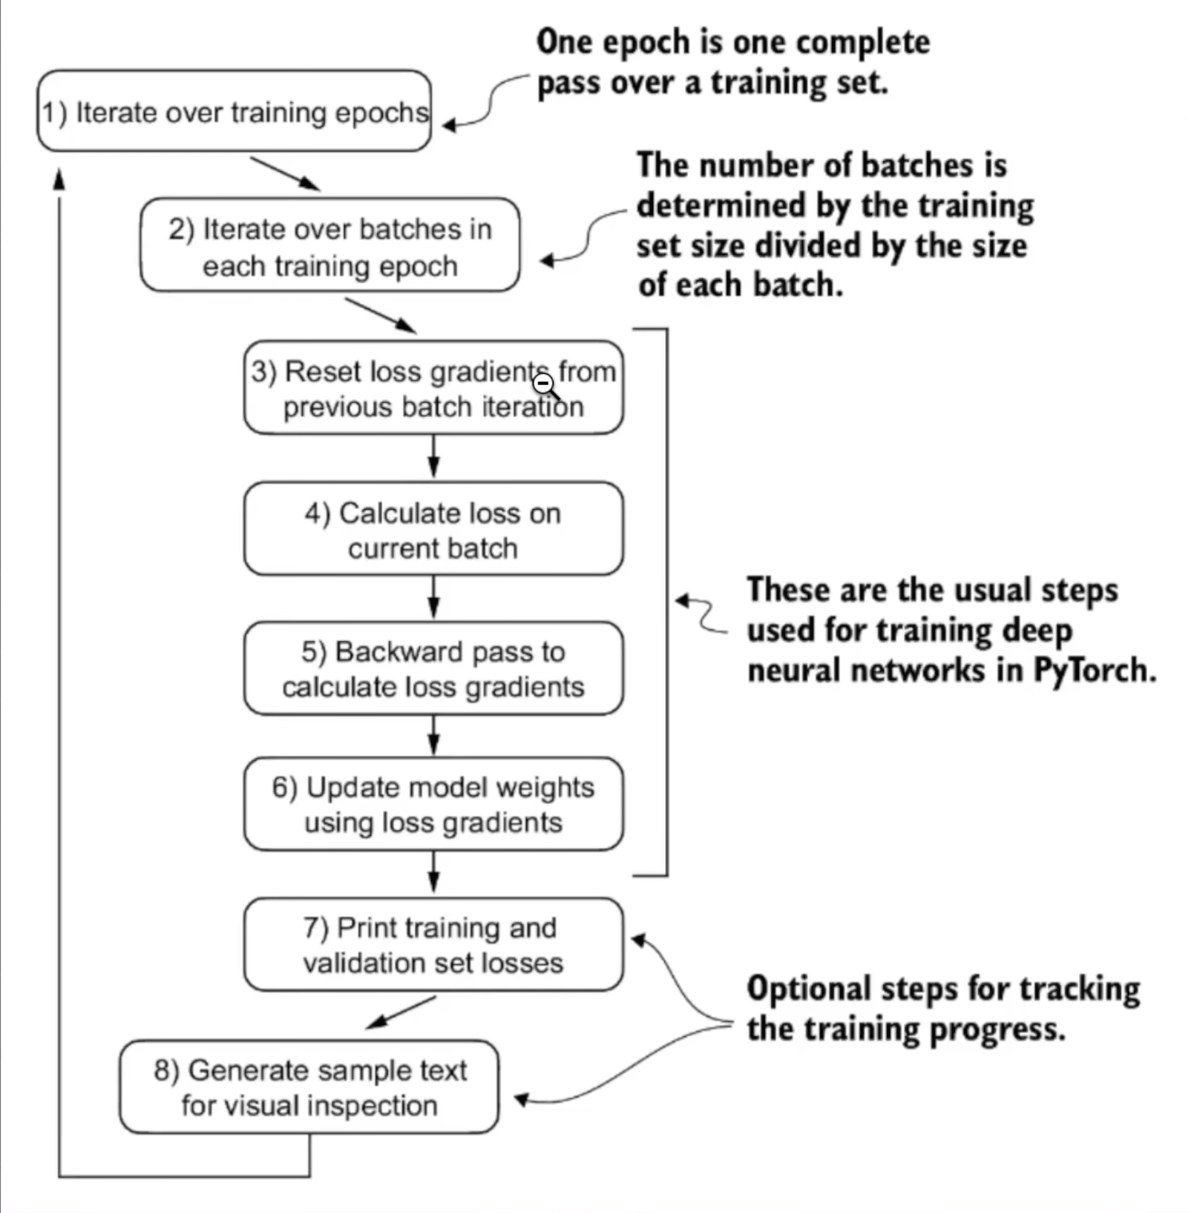

In [46]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train() # Set model to training mode, why? what does is do?

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # we do evaluation for every 10 steps maybe
            if global_step % eval_freq == 0:
                train_loss,  val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
        
        generate_and_print_sample(model, tokenizer, device, start_context)
    
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches= eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches= eval_iter)
    
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0] # how is this context size?
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx = encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " ")) # compact print format
    model.train()

In [47]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay= 0.1)

In [48]:
num_epochs = 10
train_losses, val_losses , tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq= 5, eval_iter=5,
    start_context="Every effort moves you", tokenizer= tokenizer
)

Ep 1 (Step 000000): Train loss 9.778, Val loss 9.927
Ep 1 (Step 000005): Train loss 8.115, Val loss 8.335
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.665, Val loss 7.045
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.614
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.645, Val loss 6.535
Ep 3 (Step 000025): Train loss 5.391, Val loss 6.377
Every effort moves you know parcel KokAPS ceramic vibrantgirls temperatures gau Kok, and Mrs. Gisburn, and no, andam, and left behind, and I had been no placed to have my elbow, and, and up, and's, and, and
Ep 4 (Step 000030): Train loss 5.260, Val loss 6.383
Ep 4 (Step 000035): Train loss 4.666, Val loss 6.324
Every effort moves you know it's.                                              
Ep 5 (Step 000040): Train loss 4.212, Val loss 6.207
Every effort moves

- Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7)
- Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions
- Even if you are running the example on a CPU, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

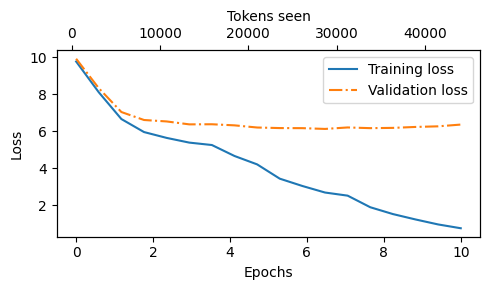

In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize = (5, 3))

    # plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label = "Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle = "-.", label = "Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc = "upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer = True)) # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)




## 5.3 Decoding strategies to control randomness

In [ ]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer
    ),
    max_new_tokens= 25,
    context_size= GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was not that my hostess was "interesting": on that point I could have given Miss Croft the fact,


## 5.3.1 Temperature scaling

In [51]:
vocab = {
    "closer" : 0,
    "every" : 1,
    "effort" : 2,
    "forward" : 3,
    "inches" : 4,
    "moves" : 5,
    "pizza" : 6,
    "toward" : 7,
    "you" : 8
}
inverse_vocab = {v: k for k, v in vocab.items()}
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [52]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63,-1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim = 0)
probas

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [53]:
next_token_id=  torch.argmax(probas).item()
next_token_id

3

In [54]:
inverse_vocab[next_token_id]

'forward'

In [55]:
# torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples= 1).item()
print(inverse_vocab[next_token_id])

forward


In [56]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)] # why is 1000 written as 1_000
    sample_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sample_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [57]:
def softmax_with_temparature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim = 0)

In [58]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temparature(next_token_logits, T) for T in temperatures]

In [59]:
scaled_probas

[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
         1.0120e-04, 3.5758e-01, 4.0122e-03]),
 tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
         2.9718e-38, 9.0133e-03, 2.8514e-22]),
 tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]

In [60]:
scaled_probas[0]

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [61]:
probas

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [62]:
scaled_probas[1]

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])

In [63]:
scaled_probas[2]

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])

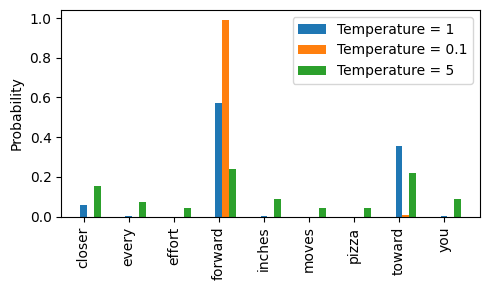

In [64]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- We can see that the rescaling via temperature 0.1 results in a sharper distribution, approaching `torch.argmax`, such that the most likely word is almost always selected:

In [65]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward


- The rescaled probabilities via temperature 5 are more uniformly distributed:

In [66]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times)

### 5.3.2 Top-k Sampling

- To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=500px>

- (Please note that the numbers in this figure are truncated to two
digits after the decimal point to reduce visual clutter. The values in the Softmax row should add up to 1.0.)

In [67]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63,-1.62, -1.89, 6.28, 1.79]
)


In [68]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print(top_logits, top_pos)

tensor([6.7500, 6.2800, 4.5100]) tensor([3, 7, 0])


In [69]:
new_logits = torch.where(
    condition= next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other = next_token_logits,
)

new_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [70]:
torch.softmax(new_logits, dim = 0)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

### 5.3.3 Modifying the text generation function to include sampling techniques discussed above

In [71]:
tokenizer.decode([50256])


'<|endoftext|>'

In [111]:
def generate(model, idx, max_new_tokens, context_size, temparature = 0.0, top_k = None, eos_id = None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            logits = torch.where(
                condition= logits < top_logits[:, -1],
                input = torch.tensor(float("-inf")).to(logits.device),
                other = logits,
            )
        if temparature > 0.0:
            logits = logits / temparature
            probs = torch.softmax(logits, dim = -1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim = -1, keepdim = True)

        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim = 1)
    return idx

In [112]:
torch.manual_seed(123)
token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens= 15,
    context_size= GPT_CONFIG_124M["context_length"],
    top_k= 25,
    temparature= 1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you can," was not that my friend in his! The fact with random enough


## 5.4 Loading and saving model weights in PyTorch

In [113]:
torch.save(model.state_dict(), "model.pth")

## 5.5 Loading pretrained weights from OpenAI

In [114]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.21.0
tqdm version: 4.67.3


In [115]:
from gpt_download import download_and_load_gpt2

In [116]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [117]:
print("Settings: ", settings)

Settings:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [118]:
print("Paramter dictionary keys:", params.keys())

Paramter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [119]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [120]:
# Definde model configurations in a dictionary for compactness

GPT_CONFIG_124M = {
    "vocab_size" : 50257,
    "context_length" : 256,
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_rate" : 0.1,
    "qkv_bias" : False
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

#  Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [121]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    
    return torch.nn.Parameter(torch.tensor(right))

In [122]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.token_emb.weight = assign(gpt.token_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [123]:
torch.manual_seed(123)
token_ids = generate(
    model = gpt,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens= 25,
    context_size= NEW_CONFIG["context_length"],
    top_k= 50,
    temparature= 1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward moving toward goals. [ goals. effort toward effort toward your effort toward goals. effort efforts efforts efforts efforts toward goals toward
